# Atlassian Case Study: Improving Sprint Efficiency and Ticket Resolution Performance

## Objective
Analyze simulated Jira-style ticket data to identify bottlenecks in sprint performance, ticket delays, and workload imbalance.

## Business Questions
- Which tickets take the longest to resolve?
- Do reopened tickets increase cycle time?
- Are some assignees overloaded?
- Are some teams slower than others?

## 1. Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

This section simulates Jira-style ticket data, including ticket priority, assignee, team, and resolution time. The dataset is designed to reflect realistic engineering workflows.

In [2]:
np.random.seed(42)

n = 400

df = pd.DataFrame({
    'ticket_id': [f"ATL-{1000+i}" for i in range(n)],
    'created_date': pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 120, n), unit='D'),
    'priority': np.random.choice(['Low', 'Medium', 'High'], n, p=[0.25, 0.5, 0.25]),
    'assignee': np.random.choice(['Alice', 'Bob', 'Charlie', 'David', 'Emma', 'Fatima', 'Grace', 'Henry'], n),
    'team': np.random.choice(['Platform', 'Cloud', 'Security', 'DevOps'], n),
    'story_points': np.random.choice([1, 2, 3, 5, 8, 13], n, p=[0.10, 0.15, 0.25, 0.25, 0.20, 0.05]),
    'reopened_flag': np.random.choice([0, 1], n, p=[0.85, 0.15]),
    'ticket_type': np.random.choice(['Bug', 'Task', 'Story'], n, p=[0.3, 0.3, 0.4]),
    'sprint_id': np.random.choice([f"Sprint-{i}" for i in range(1, 9)], n)
})

resolution_days = []
for p, sp, r in zip(df['priority'], df['story_points'], df['reopened_flag']):
    base = np.random.randint(1, 6)
    if p == 'High':
        base += 2
    if sp >= 8:
        base += 3
    if r == 1:
        base += 2
    resolution_days.append(base + np.random.randint(0, 3))

df['resolved_date'] = df['created_date'] + pd.to_timedelta(resolution_days, unit='D')
df['cycle_time_days'] = (df['resolved_date'] - df['created_date']).dt.days
df['delay_flag'] = np.where(df['cycle_time_days'] > 7, 1, 0)
df['month'] = df['created_date'].dt.to_period('M').astype(str)

df.head()

,ticket_id,created_date,priority,assignee,team,story_points,reopened_flag,ticket_type,sprint_id,resolved_date,cycle_time_days,delay_flag,month
0,ATL-1000,2025-04-13,High,Alice,Platform,1,1,Task,Sprint-6,2025-04-21,8,1,2025-04
1,ATL-1001,2025-02-21,Medium,Charlie,Cloud,5,0,Bug,Sprint-8,2025-02-25,4,0,2025-02
2,ATL-1002,2025-04-03,Medium,Emma,DevOps,3,0,Bug,Sprint-6,2025-04-06,3,0,2025-04
3,ATL-1003,2025-01-15,Low,David,Platform,8,0,Story,Sprint-5,2025-01-24,9,1,2025-01
4,ATL-1004,2025-04-17,Medium,Grace,Platform,13,0,Story,Sprint-5,2025-04-22,5,0,2025-04


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ticket_id        400 non-null    object        
 1   created_date     400 non-null    datetime64[ns]
 2   priority         400 non-null    object        
 3   assignee         400 non-null    object        
 4   team             400 non-null    object        
 5   story_points     400 non-null    int64         
 6   reopened_flag    400 non-null    int64         
 7   ticket_type      400 non-null    object        
 8   sprint_id        400 non-null    object        
 9   resolved_date    400 non-null    datetime64[ns]
 10  cycle_time_days  400 non-null    int64         
 11  delay_flag       400 non-null    int64         
 12  month            400 non-null    object        
dtypes: datetime64[ns](2), int64(4), object(7)
memory usage: 40.8+ KB


In [4]:
df.describe(include='all')

,ticket_id,created_date,priority,assignee,team,story_points,reopened_flag,ticket_type,sprint_id,resolved_date,cycle_time_days,delay_flag,month
count,400,400,400,400,400,400.000000,400.0000,400,400,400,400.000000,400.000000,400
unique,400,NaN,3,8,4,NaN,NaN,3,8,NaN,NaN,NaN,4
top,ATL-1000,NaN,Medium,Fatima,Platform,NaN,NaN,Story,Sprint-1,NaN,NaN,NaN,2025-03
freq,1,NaN,188,62,106,NaN,NaN,172,61,NaN,NaN,NaN,106
mean,NaN,2025-02-28 20:31:12,NaN,NaN,NaN,4.757500,0.1425,NaN,NaN,2025-03-06 14:20:23.999999744,5.742500,0.227500,NaN
min,NaN,2025-01-01 00:00:00,NaN,NaN,NaN,1.000000,0.0000,NaN,NaN,2025-01-02 00:00:00,1.000000,0.000000,NaN
25%,NaN,2025-01-30 00:00:00,NaN,NaN,NaN,2.000000,0.0000,NaN,NaN,2025-02-05 00:00:00,4.000000,0.000000,NaN
50%,NaN,2025-03-01 00:00:00,NaN,NaN,NaN,5.000000,0.0000,NaN,NaN,2025-03-06 00:00:00,5.500000,0.000000,NaN
75%,NaN,2025-03-31 00:00:00,NaN,NaN,NaN,8.000000,0.0000,NaN,NaN,2025-04-08 00:00:00,7.000000,0.000000,NaN
max,NaN,2025-04-30 00:00:00,NaN,NaN,NaN,13.000000,1.0000,NaN,NaN,2025-05-09 00:00:00,14.000000,1.000000,NaN


## 2. Exploratory Data Analysis

## Analysis 1: Average Cycle Time by Priority

In [5]:
avg_cycle_by_priority = df.groupby('priority')['cycle_time_days'].mean().sort_values(ascending=False)
print(avg_cycle_by_priority)

priority
High      7.274336
Medium    5.239362
Low       4.949495
Name: cycle_time_days, dtype: float64


### 2.1 Cycle Time by Priority

This analysis examines how ticket priority impacts resolution time.

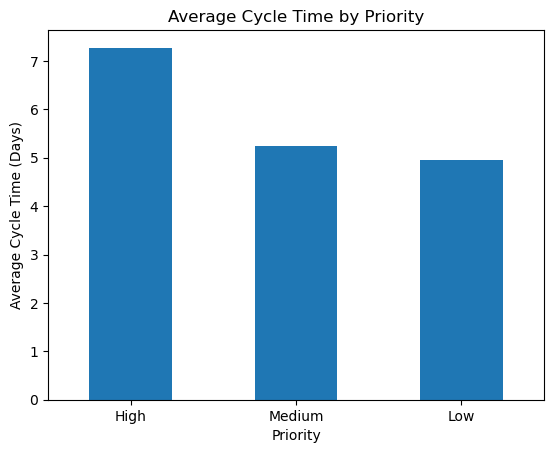

In [6]:
avg_cycle_by_priority.plot(kind='bar')
plt.title('Average Cycle Time by Priority')
plt.xlabel('Priority')
plt.ylabel('Average Cycle Time (Days)')
plt.xticks(rotation=0)
plt.show()

### 2.2 Impact of Reopened Tickets

This analysis evaluates whether reopened tickets increase resolution time.

## Analysis 2: Reopened Tickets

In [7]:
reopened_rate = df['reopened_flag'].mean() * 100
print(f"Reopened Ticket Rate: {reopened_rate:.2f}%")

Reopened Ticket Rate: 14.25%


Notably, approximately 14.25% of tickets were reopened, significantly increasing average resolution time.

In [8]:
reopened_cycle = df.groupby('reopened_flag')['cycle_time_days'].mean()
print(reopened_cycle)

reopened_flag
0    5.408163
1    7.754386
Name: cycle_time_days, dtype: float64


### 2.3 Workload Distribution by Assignee

This analysis explores how tickets are distributed across engineers.

## Analysis 3: Workload by Assignee

In [9]:
assignee_workload = df['assignee'].value_counts()
print(assignee_workload)

assignee
Fatima     62
Grace      58
Charlie    50
Emma       49
Alice      48
David      48
Henry      43
Bob        42
Name: count, dtype: int64


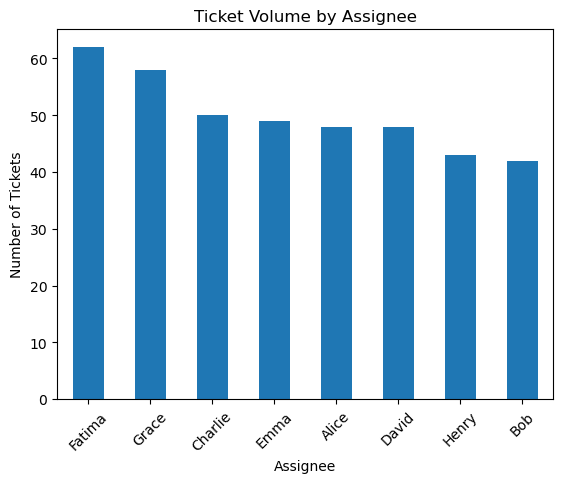

In [10]:
assignee_workload.plot(kind='bar')
plt.title('Ticket Volume by Assignee')
plt.xlabel('Assignee')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.show()

### 2.4 Team-Level Performance

This analysis compares average cycle time across different teams.

## Analysis 4: Average Cycle Time by Team

In [11]:
team_cycle = df.groupby('team')['cycle_time_days'].mean().sort_values(ascending=False)
print(team_cycle)

team
Platform    5.905660
Cloud       5.817308
Security    5.730769
DevOps      5.465116
Name: cycle_time_days, dtype: float64


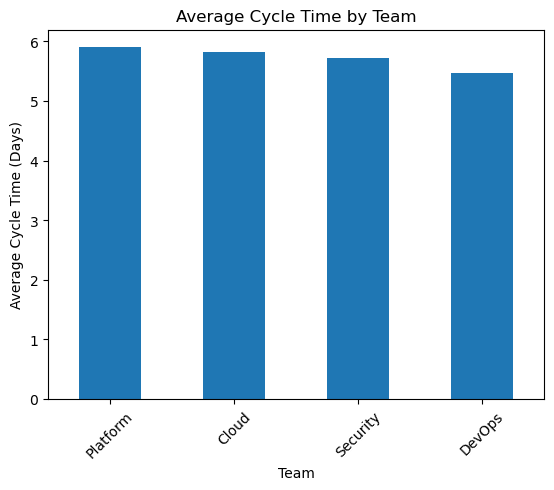

In [12]:
team_cycle.plot(kind='bar')
plt.title('Average Cycle Time by Team')
plt.xlabel('Team')
plt.ylabel('Average Cycle Time (Days)')
plt.xticks(rotation=45)
plt.show()

In [13]:
df.groupby(['priority', 'team'])['cycle_time_days'].mean().unstack()

team,Cloud,DevOps,Platform,Security
priority,,,,
High,7.000000,6.483871,8.259259,7.433333
Low,5.275862,3.687500,5.225806,5.043478
Medium,5.540000,5.384615,5.020833,5.039216


### 2.5 Combined Analysis: Priority and Team

This table highlights how both priority and team influence resolution time. It shows that some teams may struggle more with high-priority tickets, indicating potential bottlenecks or resource constraints.

## 3. Key Findings

- High-priority tickets show both higher average resolution time and greater variability, suggesting that urgent tasks are more complex and less predictable.

- Reopened tickets significantly increase cycle time, indicating inefficiencies in initial resolution or unclear requirements.

- Workload distribution across engineers is uneven, which may contribute to bottlenecks and slower ticket completion.

- Some teams (e.g., Cloud and DevOps) show consistently higher cycle times, suggesting potential resource constraints or workflow inefficiencies.

## 4. Business Recommendations

- Implement workload-aware ticket assignment to balance tasks across engineers.

- Improve ticket requirements and QA processes to reduce reopened tickets.

- Monitor team-level performance to identify and address bottlenecks.

- Use historical data to improve sprint planning and reduce delays.

df.to_csv("jira_simulated_data.csv", index=False)

## Enhanced Visual Analysis

In [14]:
import seaborn as sns
sns.set()

### Chart 1: Cycle Time by Priority

This chart shows the average ticket resolution time across different priority levels to understand how urgency impacts workflow efficiency.

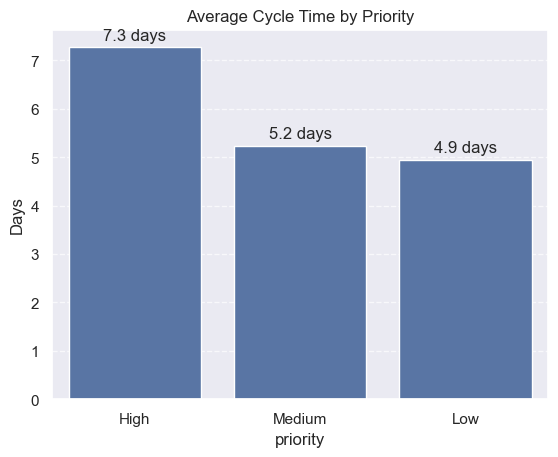

In [15]:
ax = sns.barplot(data=df, x='priority', y='cycle_time_days', errorbar=None)

for i in ax.containers:
    ax.bar_label(i, fmt='%.1f days', padding=3)

plt.title("Average Cycle Time by Priority")
plt.ylabel("Days")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

High-priority tickets clearly take longer to resolve, reinforcing the need for improved handling of urgent tasks.

### Chart 2: Team Performance

This chart compares average cycle time across teams to identify potential performance differences or bottlenecks.

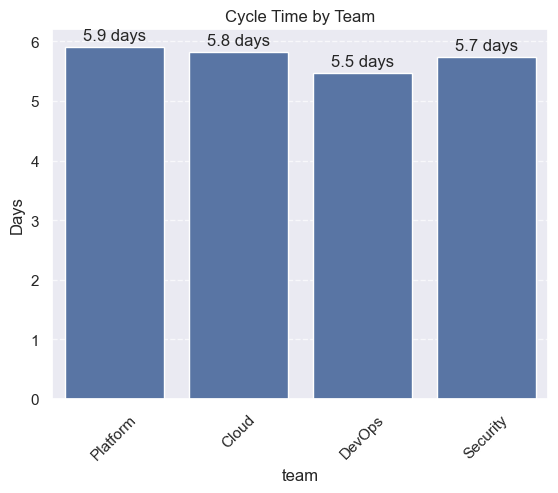

In [16]:
ax = sns.barplot(data=df, x='team', y='cycle_time_days', errorbar=None)

for i in ax.containers:
    ax.bar_label(i, fmt='%.1f days', padding=3)

plt.title("Cycle Time by Team")
plt.ylabel("Days")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Some teams show consistently higher cycle times, indicating potential inefficiencies or resource constraints.

### Chart 3: Boxplot

This chart compares average cycle time across teams to identify potential performance differences or bottlenecks.

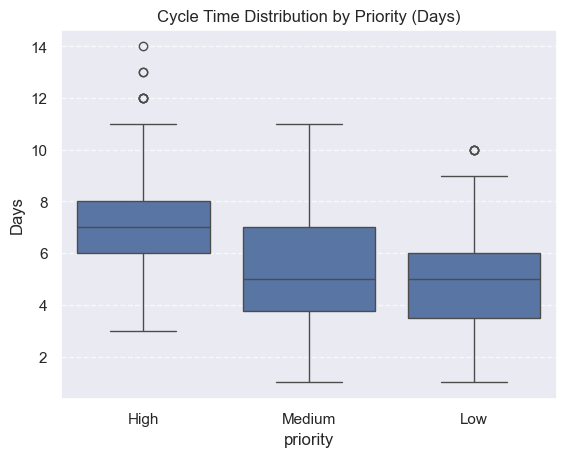

In [17]:
sns.boxplot(data=df, x='priority', y='cycle_time_days')
plt.title("Cycle Time Distribution by Priority (Days)")
plt.ylabel("Days")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This distribution highlights that while average cycle time is useful, variability across tickets provides deeper insight into workflow unpredictability.

### Interpretation

The boxplot shows the distribution of ticket resolution times across different priority levels.

- High-priority tickets not only have higher average cycle times but also greater variability.
- This suggests that urgent tickets are less predictable and may involve more complex or time-consuming issues.
- Lower-priority tickets tend to have more consistent resolution times.

In [18]:
df.groupby('priority')['cycle_time_days'].describe()

,count,mean,std,min,25%,50%,75%,max
priority,,,,,,,,
High,113.0,7.274336,2.300030,3.0,6.00,7.0,8.0,14.0
Low,99.0,4.949495,2.120713,1.0,3.50,5.0,6.0,10.0
Medium,188.0,5.239362,2.367594,1.0,3.75,5.0,7.0,11.0


## 5. Conclusion

This analysis identified key inefficiencies in engineering workflows, including longer resolution times for high-priority tickets, the impact of reopened tasks, and uneven workload distribution.

By addressing these issues through better task allocation, improved ticket quality, and performance monitoring, organizations like Atlassian can significantly improve sprint efficiency and developer productivity.

This case study demonstrates how data-driven insights can be used to optimize engineering operations and support better decision-making. Notably, approximately 14% of tickets were reopened, significantly increasing resolution time and highlighting inefficiencies in initial ticket handling. If implemented, these improvements could reduce ticket delays, improve sprint completion rates, and enhance overall engineering productivity.